In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("uploaded success！")

uploaded success！


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Online_retail II.csv', encoding='latin-1')
print(df.shape)
print(df.head())

(1048575, 8)
                                             Invoice StockCode  \
0                                             489434     85048   
1                                             489434    79323P   
2                                             489434    79323W   
3  489434,22041,"RECORD FRAME 7"" SINGLE SIZE ",4...       NaN   
4                                             489434     21232   

                           Description  Quantity          InvoiceDate  Price  \
0  15CM CHRISTMAS GLASS BALL 20 LIGHTS      12.0  2009-12-01 07:45:00   6.95   
1                   PINK CHERRY LIGHTS      12.0  2009-12-01 07:45:00   6.75   
2                  WHITE CHERRY LIGHTS      12.0  2009-12-01 07:45:00   6.75   
3                                  NaN       NaN                  NaN    NaN   
4       STRAWBERRY CERAMIC TRINKET BOX      24.0  2009-12-01 07:45:00   1.25   

   Customer ID         Country  
0      13085.0  United Kingdom  
1      13085.0  United Kingdom  
2      130

In [11]:
# data cleaning
df.columns = df.columns.str.strip()
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df['TotalAmount'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Clean data: {df.shape}")
print(df['TotalAmount'].describe())

Clean data: (780926, 9)
count    780926.000000
mean         21.930472
std         123.633735
min           0.001000
25%           4.950000
50%          11.900000
75%          19.500000
max       77183.600000
Name: TotalAmount, dtype: float64


In [12]:
# RFM
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
print(rfm.shape)
print(rfm.head())
print(rfm.describe())

(5857, 4)
   CustomerID  Recency  Frequency  Monetary
0     12346.0      321         12  77556.46
1     12347.0       35          7   5357.50
2     12348.0       71          5   2019.40
3     12349.0       14          4   4362.99
4     12350.0      305          1    334.40
         CustomerID      Recency    Frequency       Monetary
count   5857.000000  5857.000000  5857.000000    5857.000000
mean   15316.515793   200.979853     6.217005    2924.035475
std     1714.501330   207.542856    12.843220   14163.180156
min    12346.000000     1.000000     1.000000       2.900000
25%    13836.000000    26.000000     1.000000     339.600000
50%    15316.000000   101.000000     3.000000     869.920000
75%    16799.000000   376.000000     7.000000    2246.750000
max    18287.000000   734.000000   391.000000  587591.270000


In [13]:
# K-means clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# see Ave by groups
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1))
print('\nCluster sizes:')
print(rfm['Cluster'].value_counts())

         Recency  Frequency  Monetary
Cluster                              
0          458.3        2.2     744.0
1           67.3        7.4    3070.4
2           21.8      135.4  111913.4
3            9.5      145.0  547264.6

Cluster sizes:
Cluster
1    3824
0    2006
2      25
3       2
Name: count, dtype: int64


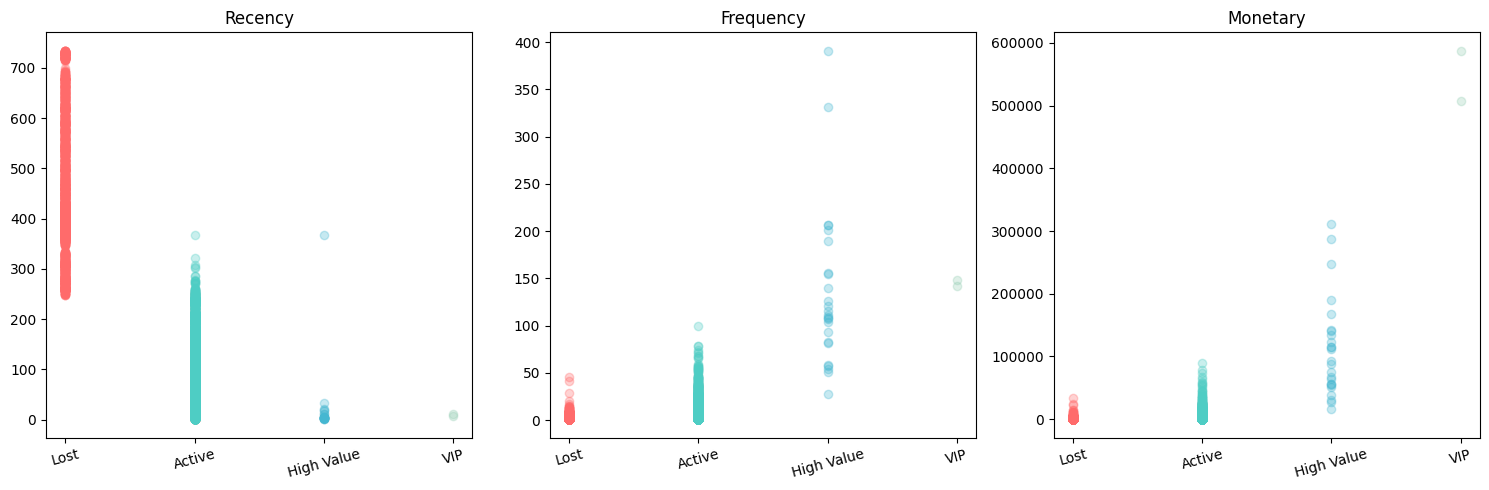

In [14]:
# visualization
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']
labels = ['Lost', 'Active', 'High Value', 'VIP']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(['Recency', 'Frequency', 'Monetary']):
    for cluster in range(4):
        data = rfm[rfm['Cluster']==cluster][metric]
        axes[i].scatter([cluster]*len(data), data,
                       alpha=0.3, c=colors[cluster])
    axes[i].set_title(metric)
    axes[i].set_xticks(range(4))
    axes[i].set_xticklabels(labels, rotation=15)

plt.tight_layout()
plt.savefig('rfm_clusters.png', dpi=150)
plt.show()

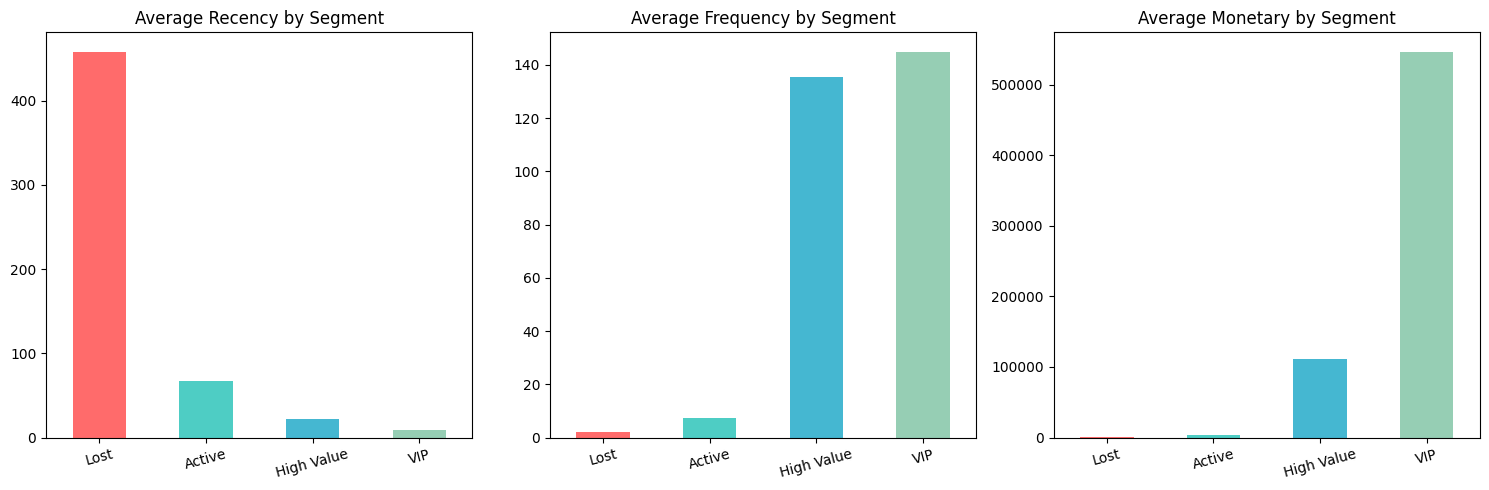

In [15]:
# bar chart：AVG RFM by group
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
cluster_summary.index = ['Lost','Active','High Value','VIP']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#ff6b6b','#4ecdc4','#45b7d1','#96ceb4']

for i, metric in enumerate(['Recency','Frequency','Monetary']):
    cluster_summary[metric].plot(kind='bar', ax=axes[i], color=colors)
    axes[i].set_title(f'Average {metric} by Segment')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('rfm_bar.png', dpi=150)
plt.show()